# Zoomed Visualization: UConn Forest (UC) & Ruby Park (RP)
**Steady-State and Transient MODFLOW 6 Results**

Author: Lijing Wang (lijing.wang@uconn.edu) for ERTH 4750 at University of Connecticut

This notebook produces zoomed-in hydraulic head maps for two sub-regions within the Fenton watershed:

| Region | Code | Northing (approx.) | Description |
|--------|------|--------------------|-------------|
| UConn Forest | UC | ~4,635,400 m | Southern beaver dam cluster |
| Ruby Park    | RP | ~4,643,000 m | Northern beaver dam cluster |

Beaver dam locations are read from `model_inputs/Beaver_dam_UC_RP.shp` (EPSG:26919).  
Model results come from the Fenton steady-state (`ERTH4750_SS_DataDriven`) and transient (`ERTH4750_TR_DataDriven`) workspaces.

**Before running:** Execute `05_Steady_State_MODFLOW.ipynb` and `06_Transient_MODFLOW_new.ipynb` first.

In [1]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/MODFLOW_Lab/Fenton'
    os.chdir(DRIVE_DIR)
    print('Working directory →', os.getcwd())
else:
    print('Local: working directory →', os.getcwd())

Local: working directory → /mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/MODFLOW/UConn_MODFLOW_fenton/Fenton


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize

import geopandas as gpd
import rasterio as rio
import flopy
from flopy.plot import PlotMapView
from flopy.utils.postprocessing import get_water_table

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
data_dir   = Path('')          # run notebook from Fenton/
inputs_dir = data_dir / 'model_inputs'

if IN_COLAB:
    mf6_exe = 'mf6'
else:
    mf6_exe = str(Path.home() / 'bin' / 'mf6')

WS_SS   = str(data_dir / 'ERTH4750_SS_DataDriven')
WS_TR   = str(data_dir / 'ERTH4750_TR_DataDriven')
NAME_SS = 'ss_datadriven'
NAME_TR = 'tr_datadriven'

# ── Zoom buffer around each beaver-dam cluster ──────────────────────────────
BUFFER_M = 300   # metres padding around each site

print('SS workspace :', WS_SS)
print('TR workspace :', WS_TR)

SS workspace : ERTH4750_SS_DataDriven
TR workspace : ERTH4750_TR_DataDriven


## 1  Load & Inspect Shapefiles

In [4]:
# ── Beaver dam locations (UC + RP) ─────────────────────────────────────────
beaver_raw  = gpd.read_file(inputs_dir / 'Beaver_dam_UC_RP.shp')   # EPSG:26919
streams_raw = gpd.read_file(inputs_dir / 'streams_nhd.shp')

# Get model CRS from the DEM so all shapefiles are in the same system
with rio.open(inputs_dir / 'dem_10m.tif') as src:
    model_crs = src.crs

beaver   = beaver_raw.to_crs(model_crs)
streams  = streams_raw.to_crs(model_crs)

print('Model CRS  :', model_crs)
print('Beaver CRS (original):', beaver_raw.crs)
print(f'Beaver dams: {len(beaver)} features, geom={beaver.geom_type.unique()}')
print(f'Columns    : {beaver.columns.tolist()}')
print(f'Total bounds (model CRS):')
print(f'  x: {beaver.total_bounds[0]:.1f} – {beaver.total_bounds[2]:.1f}')
print(f'  y: {beaver.total_bounds[1]:.1f} – {beaver.total_bounds[3]:.1f}')

/home/yeonju/miniconda3/lib/python3.13/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


Model CRS  : EPSG:32618
Beaver CRS (original): EPSG:26919
Beaver dams: 17 features, geom=['LineString']
Columns    : ['Id', 'geometry']
Total bounds (model CRS):
  x: 729316.0 – 730036.6
  y: 4633923.4 – 4642235.0


In [5]:
# ── Split into UC (UConn Forest) and RP (Ruby Park) by northing ────────────
# Two spatial clusters visible in the data:
#   RP cluster: y ≈ 4,643,xxx  (northern group)
#   UC cluster: y ≈ 4,635,xxx  (southern group)
y_split = (beaver.geometry.apply(lambda g: g.centroid.y).max() +
           beaver.geometry.apply(lambda g: g.centroid.y).min()) / 2
print(f'Auto y-split threshold: {y_split:.1f} m')

beaver_rp = beaver[beaver.geometry.apply(lambda g: g.centroid.y) > y_split].copy()
beaver_uc = beaver[beaver.geometry.apply(lambda g: g.centroid.y) <= y_split].copy()

print(f'UC dams: {len(beaver_uc)} features')
print(f'RP dams: {len(beaver_rp)} features')

# ── Zoom extents (buffered bounding boxes) ─────────────────────────────────
def zoom_extent(gdf, buf):
    bx = gdf.total_bounds   # (minx, miny, maxx, maxy)
    return (bx[0]-buf, bx[2]+buf, bx[1]-buf, bx[3]+buf)  # xlim, ylim

ext_uc = zoom_extent(beaver_uc, BUFFER_M)
ext_rp = zoom_extent(beaver_rp, BUFFER_M)

print(f'\nUC zoom  x: {ext_uc[0]:.0f} – {ext_uc[1]:.0f}')
print(f'         y: {ext_uc[2]:.0f} – {ext_uc[3]:.0f}')
print(f'RP zoom  x: {ext_rp[0]:.0f} – {ext_rp[1]:.0f}')
print(f'         y: {ext_rp[2]:.0f} – {ext_rp[3]:.0f}')

Auto y-split threshold: 4638088.0 m
UC dams: 5 features
RP dams: 12 features

UC zoom  x: 729016 – 729896
         y: 4633623 – 4634448
RP zoom  x: 729487 – 730337
         y: 4641749 – 4642535


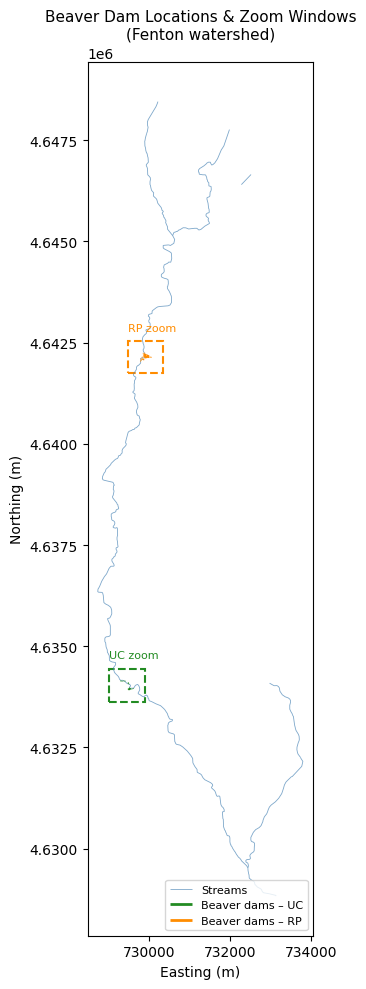

In [6]:
# ── Overview: show both zoom windows on the full domain ────────────────────
fig, ax = plt.subplots(figsize=(6, 10))
streams.plot(ax=ax, color='steelblue', lw=0.6, alpha=0.7, label='Streams')
beaver_uc.plot(ax=ax, color='forestgreen', lw=2.0, label='Beaver dams – UC')
beaver_rp.plot(ax=ax, color='darkorange',  lw=2.0, label='Beaver dams – RP')

# Draw zoom boxes
for ext, label, col in [(ext_uc, 'UC zoom', 'forestgreen'),
                         (ext_rp, 'RP zoom', 'darkorange')]:
    rect = plt.Rectangle((ext[0], ext[2]), ext[1]-ext[0], ext[3]-ext[2],
                          fill=False, edgecolor=col, lw=1.5, ls='--')
    ax.add_patch(rect)
    ax.text(ext[0], ext[3]+200, label, color=col, fontsize=8, va='bottom')

ax.set_title('Beaver Dam Locations & Zoom Windows\n(Fenton watershed)', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
## 2  Steady-State Model

In [7]:
# ── Load SS simulation ──────────────────────────────────────────────────────
sim_ss  = flopy.mf6.MFSimulation.load(
    sim_name=NAME_SS, sim_ws=WS_SS, exe_name=mf6_exe, verbosity_level=0
)
gwf_ss  = sim_ss.get_model(NAME_SS)
sgrid   = gwf_ss.modelgrid

print(f'Grid  : {sgrid.nrow} rows × {sgrid.ncol} cols, {sgrid.nlay} layers')
print(f'Cell Δ: dx={sgrid.delr[0]:.2f} m, dy={sgrid.delc[0]:.2f} m')
print(f'Extent x: {sgrid.xoffset:.1f} – {sgrid.xoffset + sgrid.ncol*sgrid.delr[0]:.1f}')
print(f'Extent y: {sgrid.yoffset:.1f} – {sgrid.yoffset + sgrid.nrow*sgrid.delc[0]:.1f}')

Grid  : 2395 rows × 1567 cols, 2 layers
Cell Δ: dx=9.16 m, dy=9.16 m
Extent x: 723623.9 – 737980.2
Extent y: 4628352.9 – 4650295.0


In [8]:
# ── Extract hydraulic head and water table ──────────────────────────────────
hobj_ss  = gwf_ss.output.head()
hds_ss   = hobj_ss.get_data().astype(float)
hds_ss[hds_ss > 1e29] = np.nan

# Water table elevation (highest active head per column)
wt_ss = get_water_table(hds_ss)

# Depth to water table
top_arr = sgrid.top.copy().astype(float)
top_arr[sgrid.idomain[0] == 0] = np.nan
depth_wt_ss = np.clip(top_arr - wt_ss, 0, None)

print(f'hds_ss shape : {hds_ss.shape}')
print(f'Head range   : {np.nanmin(hds_ss):.1f} – {np.nanmax(hds_ss):.1f} m')
print(f'Water table  : {np.nanmin(wt_ss):.1f} – {np.nanmax(wt_ss):.1f} m')

hds_ss shape : (2, 2395, 1567)
Head range   : 64.5 – 353.2 m
Water table  : 64.5 – 353.2 m


---
## 3  Transient Model

In [9]:
# ── Load TR simulation ──────────────────────────────────────────────────────
sim_tr = flopy.mf6.MFSimulation.load(
    sim_name=NAME_TR, sim_ws=WS_TR, exe_name=mf6_exe, verbosity_level=0
)
gwf_tr = sim_tr.get_model(NAME_TR)

hobj_tr = gwf_tr.output.head()
kstpkper_list = hobj_tr.get_kstpkper()
n_sp = len(kstpkper_list)
print(f'Transient stress periods (kstpkper): {n_sp}')
print('  First few:', kstpkper_list[:4])
print('  Last  few:', kstpkper_list[-4:])

Transient stress periods (kstpkper): 12
  First few: [(np.int32(8), np.int32(0)), (np.int32(7), np.int32(1)), (np.int32(7), np.int32(2)), (np.int32(7), np.int32(3))]
  Last  few: [(np.int32(7), np.int32(8)), (np.int32(7), np.int32(9)), (np.int32(7), np.int32(10)), (np.int32(7), np.int32(11))]


In [10]:
# ── Extract head for all stress periods ────────────────────────────────────
# Store as list of (nlay, nrow, ncol) arrays, one per stress period
hds_tr_all = []
for ksp in kstpkper_list:
    h = hobj_tr.get_data(kstpkper=ksp).astype(float)
    h[h > 1e29] = np.nan
    hds_tr_all.append(h)

# Water table for each stress period
wt_tr_all = [get_water_table(h) for h in hds_tr_all]

# Monthly labels (assume Jan–Dec 2025 if 12 stress periods)
import calendar
if n_sp == 12:
    month_labels = [pd.Timestamp(f'2025-{m:02d}-01').strftime('%b %Y') for m in range(1,13)]
else:
    month_labels = [f'SP{i+1}' for i in range(n_sp)]

print(f'Loaded {len(hds_tr_all)} transient snapshots')
print('Month labels:', month_labels)

Loaded 12 transient snapshots
Month labels: ['Jan 2025', 'Feb 2025', 'Mar 2025', 'Apr 2025', 'May 2025', 'Jun 2025', 'Jul 2025', 'Aug 2025', 'Sep 2025', 'Oct 2025', 'Nov 2025', 'Dec 2025']


---
## 4  Helper: Zoomed Head Map

In [11]:
def plot_zoomed_head(gwf, hds, ext, site_label, title,
                     beaver_gdf=None, streams_gdf=None,
                     cmap='RdYlBu', n_contours=30, ax=None):
    """Plot zoomed hydraulic head (Layer 1) with contours and optional overlays.

    Parameters
    ----------
    gwf        : flopy GWF model object
    hds        : (nlay, nrow, ncol) head array
    ext        : (xlim_min, xlim_max, ylim_min, ylim_max) zoom extent in model CRS
    site_label : str  — 'UC' or 'RP'
    title      : str  — axes title
    beaver_gdf : GeoDataFrame of beaver dams (optional overlay)
    streams_gdf: GeoDataFrame of streams  (optional overlay)
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    mm = PlotMapView(model=gwf, layer=0, ax=ax)
    pa = mm.plot_array(hds, cmap=cmap, alpha=0.85)

    # Contours from valid cells in zoom window
    try:
        levels = np.linspace(np.nanmin(hds[0]), np.nanmax(hds[0]), n_contours)
        mm.contour_array(hds, levels=levels, colors='k', linewidths=0.5, alpha=0.6)
    except Exception:
        pass

    # Overlay streams
    if streams_gdf is not None:
        streams_gdf.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)

    # Overlay beaver dams
    if beaver_gdf is not None:
        beaver_gdf.plot(ax=ax, color='red', lw=2.0, zorder=5,
                        label='Beaver dams')
        ax.legend(fontsize=8, loc='lower right')

    # Apply zoom
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)
    return ax


def plot_zoomed_wt(top_arr, wt, ext, site_label, title,
                   beaver_gdf=None, streams_gdf=None, gwf=None, ax=None):
    """Plot zoomed depth-to-water-table map."""
    depth = np.clip(top_arr - wt, 0, None)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if gwf is not None:
        mm = PlotMapView(model=gwf, layer=0, ax=ax)
        pa = mm.plot_array(depth[np.newaxis, :, :], cmap='YlOrBr', vmin=0)
    else:
        raise ValueError('gwf required')

    if streams_gdf is not None:
        streams_gdf.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    if beaver_gdf is not None:
        beaver_gdf.plot(ax=ax, color='red', lw=2.0, zorder=5, label='Beaver dams')
        ax.legend(fontsize=8, loc='lower right')

    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Depth to WT (m)', fontsize=8)
    return ax

---
## 5  Steady-State — UConn Forest (UC)

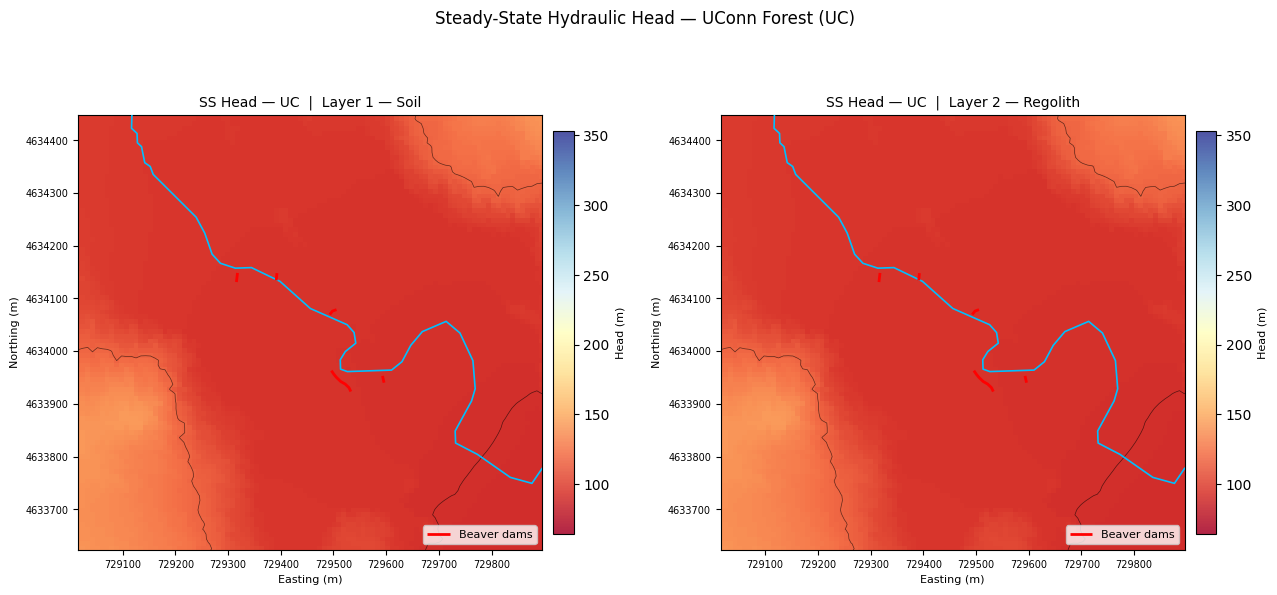

In [12]:
# ── SS head: Layer 1 (Soil) and Layer 2 (Regolith) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, lyr, lyr_label in zip(axes, [0, 1], ['Layer 1 — Soil', 'Layer 2 — Regolith']):
    mm = PlotMapView(model=gwf_ss, layer=lyr, ax=ax)
    pa = mm.plot_array(hds_ss, cmap='RdYlBu', alpha=0.85)
    levels = np.linspace(np.nanmin(hds_ss[lyr]), np.nanmax(hds_ss[lyr]), 12)
    mm.contour_array(hds_ss, levels=levels, colors='k', linewidths=0.5, alpha=0.6)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_uc.plot(ax=ax, color='red', lw=2.0, zorder=5, label='Beaver dams')
    ax.set_xlim(ext_uc[0], ext_uc[1])
    ax.set_ylim(ext_uc[2], ext_uc[3])
    ax.set_title(f'SS Head — UC  |  {lyr_label}', fontsize=10)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)

plt.suptitle('Steady-State Hydraulic Head — UConn Forest (UC)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

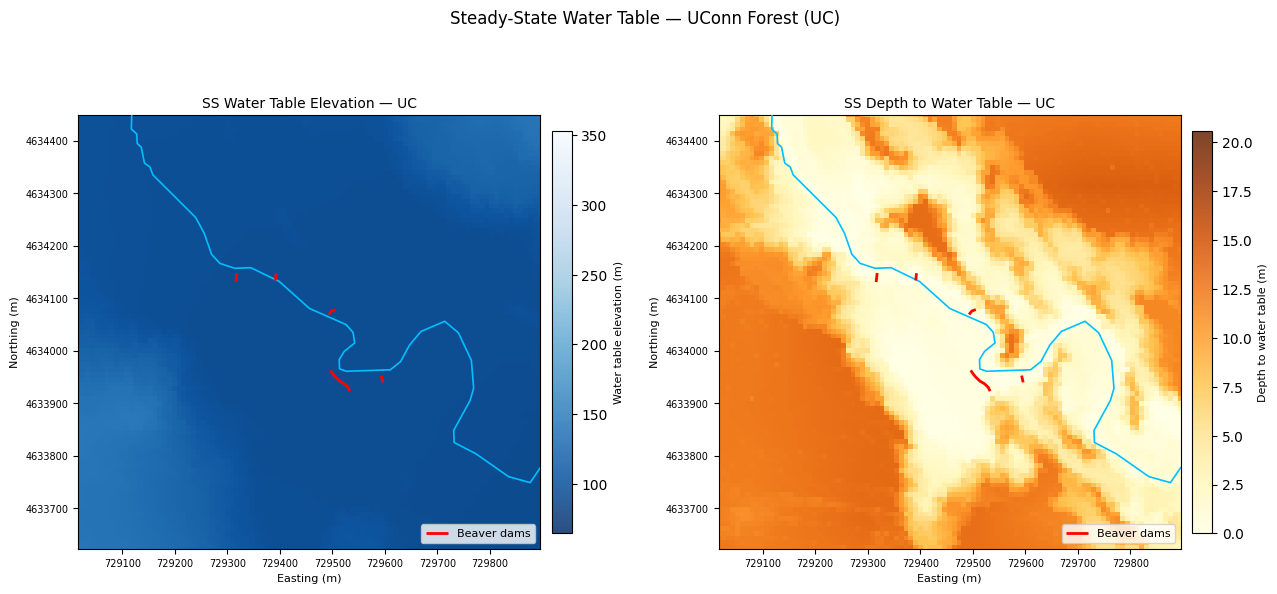

In [13]:
# ── SS depth to water table — UC ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (arr, cb_label, cmap) in zip(
    axes,
    [
        (wt_ss,       'Water table elevation (m)', 'Blues_r'),
        (depth_wt_ss, 'Depth to water table (m)',  'YlOrBr' ),
    ]
):
    mm = PlotMapView(model=gwf_ss, layer=0, ax=ax)
    pa = mm.plot_array(arr[np.newaxis, :, :], cmap=cmap, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_uc.plot(ax=ax, color='red', lw=2.0, zorder=5, label='Beaver dams')
    ax.set_xlim(ext_uc[0], ext_uc[1])
    ax.set_ylim(ext_uc[2], ext_uc[3])
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label(cb_label, fontsize=8)

axes[0].set_title('SS Water Table Elevation — UC', fontsize=10)
axes[1].set_title('SS Depth to Water Table — UC', fontsize=10)
plt.suptitle('Steady-State Water Table — UConn Forest (UC)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 6  Steady-State — Ruby Park (RP)

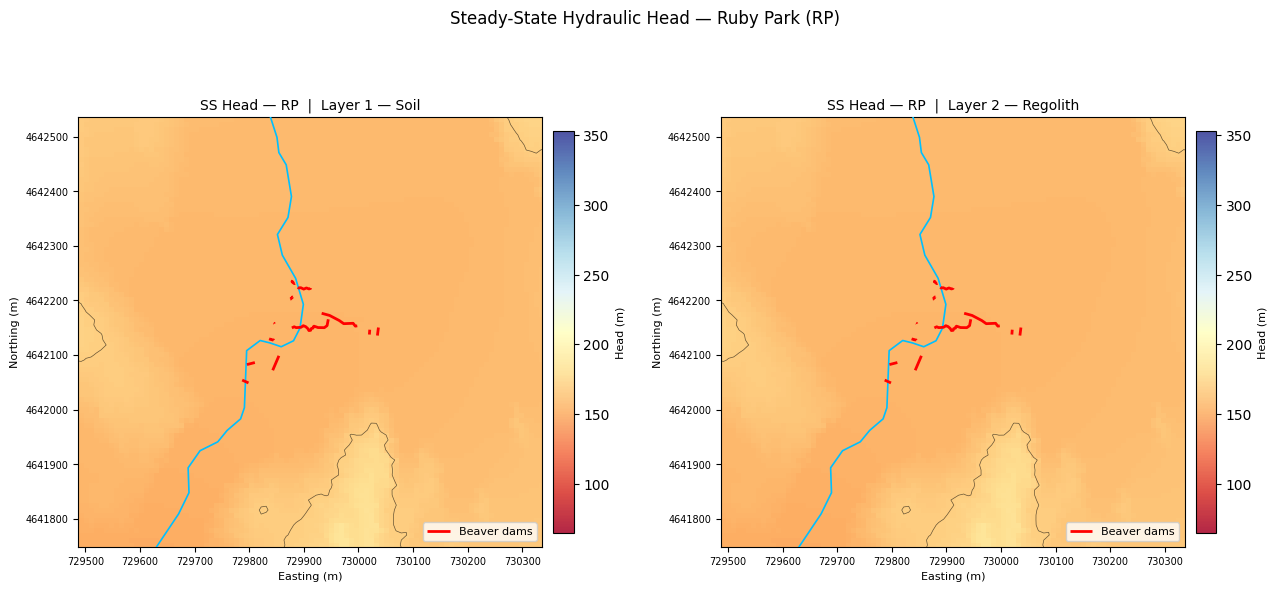

In [14]:
# ── SS head: Layer 1 (Soil) and Layer 2 (Regolith) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, lyr, lyr_label in zip(axes, [0, 1], ['Layer 1 — Soil', 'Layer 2 — Regolith']):
    mm = PlotMapView(model=gwf_ss, layer=lyr, ax=ax)
    pa = mm.plot_array(hds_ss, cmap='RdYlBu', alpha=0.85)
    levels = np.linspace(np.nanmin(hds_ss[lyr]), np.nanmax(hds_ss[lyr]), 12)
    mm.contour_array(hds_ss, levels=levels, colors='k', linewidths=0.5, alpha=0.6)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_rp.plot(ax=ax, color='red', lw=2.0, zorder=5, label='Beaver dams')
    ax.set_xlim(ext_rp[0], ext_rp[1])
    ax.set_ylim(ext_rp[2], ext_rp[3])
    ax.set_title(f'SS Head — RP  |  {lyr_label}', fontsize=10)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)

plt.suptitle('Steady-State Hydraulic Head — Ruby Park (RP)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

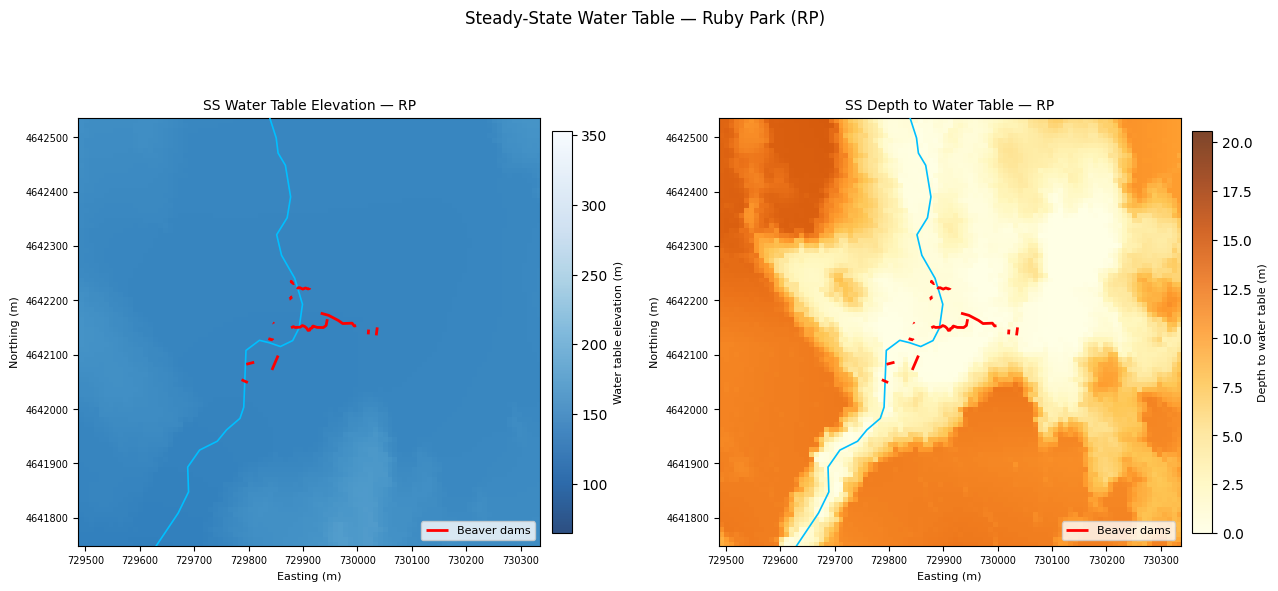

In [15]:
# ── SS depth to water table — RP ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (arr, cb_label, cmap) in zip(
    axes,
    [
        (wt_ss,       'Water table elevation (m)', 'Blues_r'),
        (depth_wt_ss, 'Depth to water table (m)',  'YlOrBr' ),
    ]
):
    mm = PlotMapView(model=gwf_ss, layer=0, ax=ax)
    pa = mm.plot_array(arr[np.newaxis, :, :], cmap=cmap, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_rp.plot(ax=ax, color='red', lw=2.0, zorder=5, label='Beaver dams')
    ax.set_xlim(ext_rp[0], ext_rp[1])
    ax.set_ylim(ext_rp[2], ext_rp[3])
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label(cb_label, fontsize=8)

axes[0].set_title('SS Water Table Elevation — RP', fontsize=10)
axes[1].set_title('SS Depth to Water Table — RP', fontsize=10)
plt.suptitle('Steady-State Water Table — Ruby Park (RP)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 7  Transient — UConn Forest (UC)
Four seasonal snapshots: Jan, Apr, Jul, Oct (stress periods 0, 3, 6, 9).

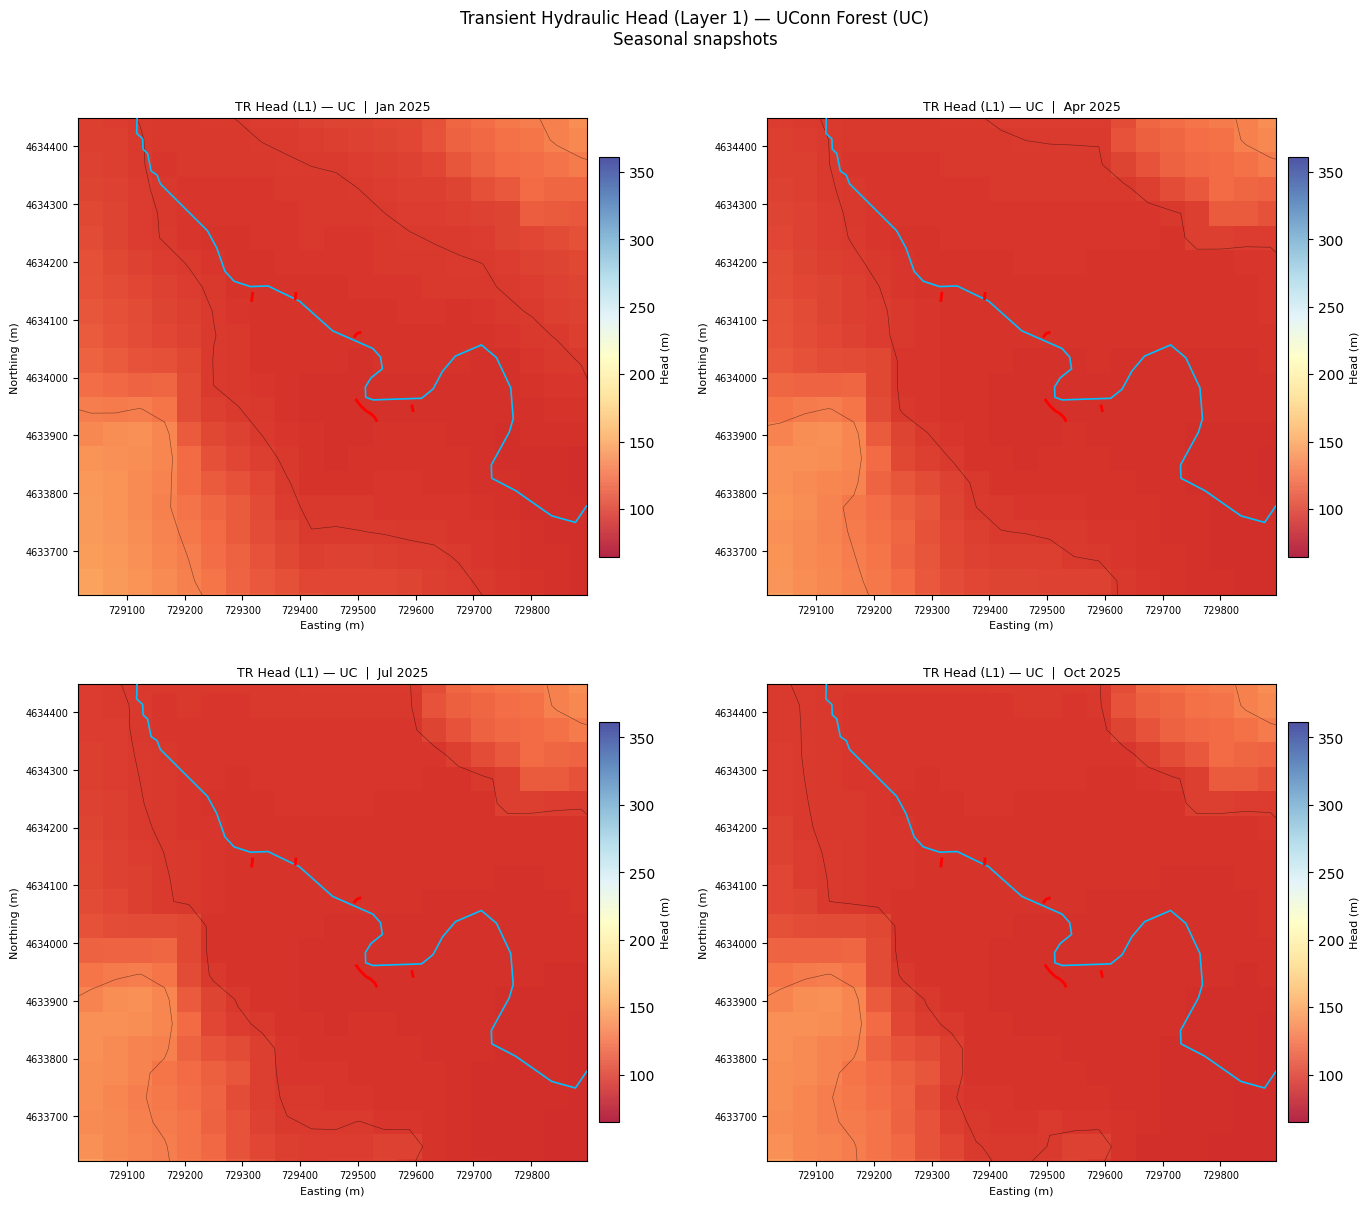

In [16]:
# ── TR head Layer 1, 4 seasonal snapshots — UC ─────────────────────────────
sp_plot = [0, 3, 6, 9] if n_sp >= 10 else list(range(min(4, n_sp)))

# Shared colorscale across all panels
vmin_h = min(np.nanmin(hds_tr_all[i][0]) for i in sp_plot)
vmax_h = max(np.nanmax(hds_tr_all[i][0]) for i in sp_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, isp in zip(axes.flat, sp_plot):
    h = hds_tr_all[isp]
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    pa = mm.plot_array(h, cmap='RdYlBu', vmin=vmin_h, vmax=vmax_h, alpha=0.85)
    levels = np.linspace(vmin_h, vmax_h, 10)
    try:
        mm.contour_array(h, levels=levels, colors='k', linewidths=0.4, alpha=0.5)
    except Exception:
        pass
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_uc.plot(ax=ax, color='red', lw=2.0, zorder=5)
    ax.set_xlim(ext_uc[0], ext_uc[1])
    ax.set_ylim(ext_uc[2], ext_uc[3])
    ax.set_title(f'TR Head (L1) — UC  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)

plt.suptitle('Transient Hydraulic Head (Layer 1) — UConn Forest (UC)\nSeasonal snapshots',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

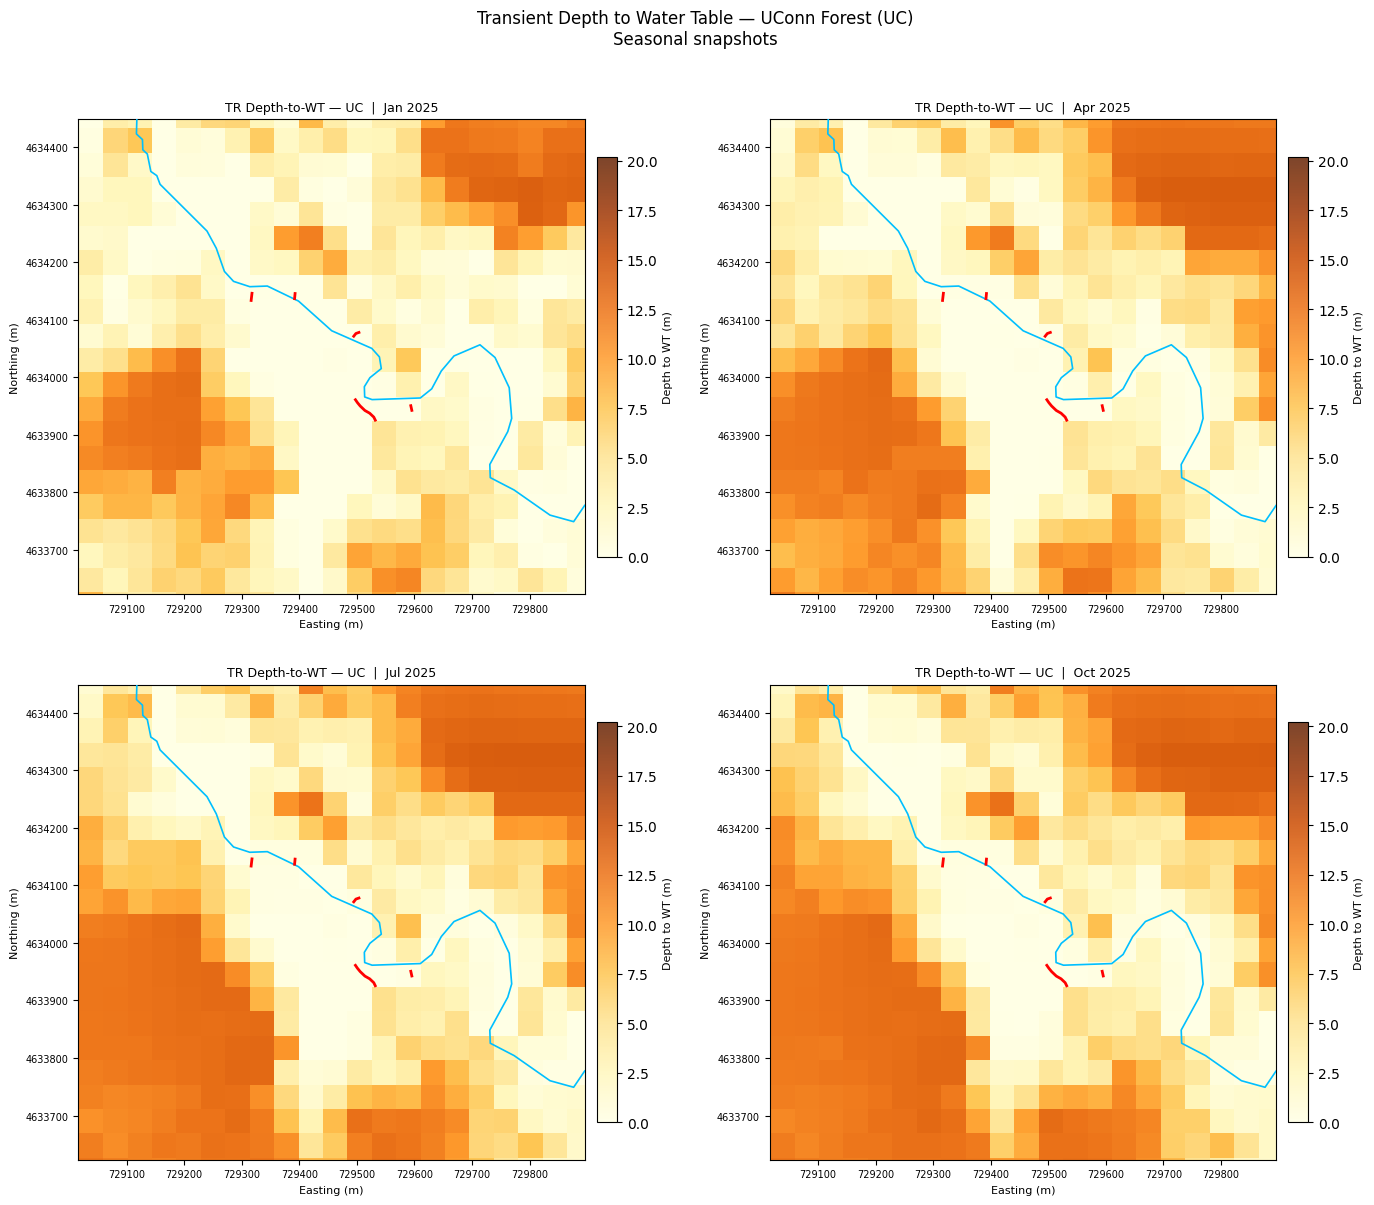

In [17]:
# ── TR depth to water table, 4 seasonal snapshots — UC ─────────────────────
top_2d = gwf_tr.modelgrid.top.copy().astype(float)
top_2d[gwf_tr.modelgrid.idomain[0] == 0] = np.nan

vmin_d = min(np.nanmin(np.clip(top_2d - wt_tr_all[i], 0, None)) for i in sp_plot)
vmax_d = max(np.nanmax(np.clip(top_2d - wt_tr_all[i], 0, None)) for i in sp_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, isp in zip(axes.flat, sp_plot):
    wt = wt_tr_all[isp]
    depth = np.clip(top_2d - wt, 0, None)
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    pa = mm.plot_array(depth[np.newaxis, :, :], cmap='YlOrBr',
                       vmin=vmin_d, vmax=vmax_d, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_uc.plot(ax=ax, color='red', lw=2.0, zorder=5)
    ax.set_xlim(ext_uc[0], ext_uc[1])
    ax.set_ylim(ext_uc[2], ext_uc[3])
    ax.set_title(f'TR Depth-to-WT — UC  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Depth to WT (m)', fontsize=8)

plt.suptitle('Transient Depth to Water Table — UConn Forest (UC)\nSeasonal snapshots',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

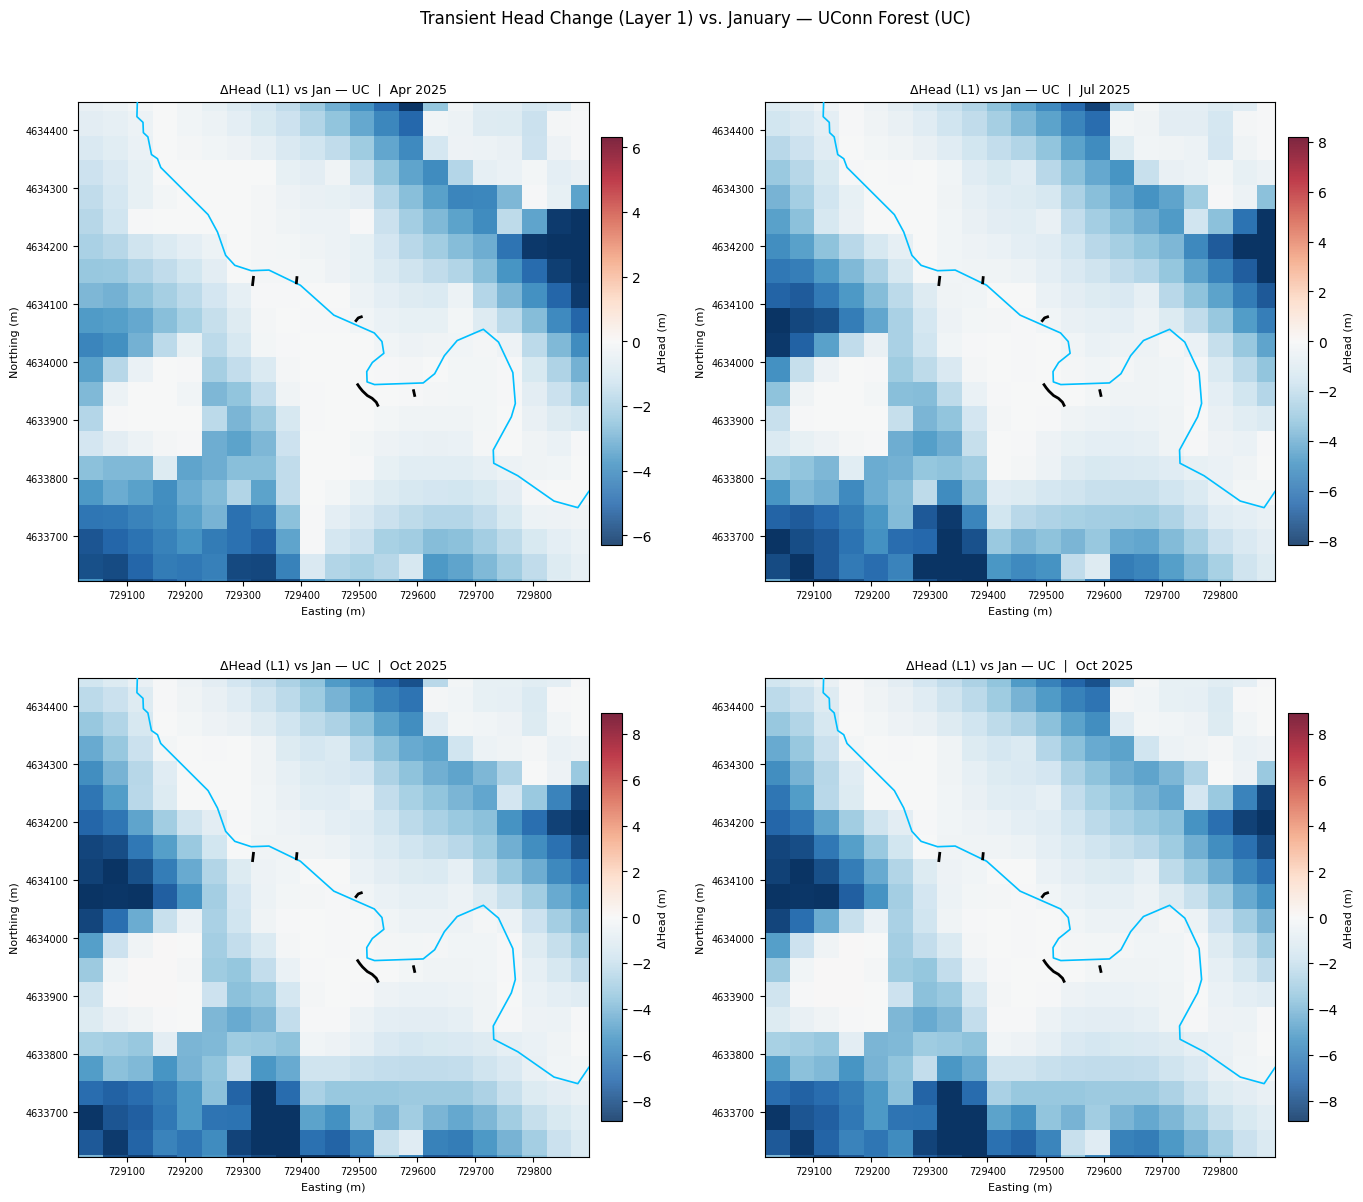

In [18]:
# ── TR head change vs. first step — UC ─────────────────────────────────────
h_ref = hds_tr_all[0][0].copy()  # Layer 1, first stress period

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, isp in zip(axes.flat, sp_plot[1:] + [sp_plot[-1]]):
    dh = hds_tr_all[isp][0] - h_ref
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    lim = np.nanpercentile(np.abs(dh), 95)
    pa = mm.plot_array(dh[np.newaxis, :, :], cmap='RdBu_r',
                       vmin=-lim, vmax=lim, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_uc.plot(ax=ax, color='k', lw=2.0, zorder=5)
    ax.set_xlim(ext_uc[0], ext_uc[1])
    ax.set_ylim(ext_uc[2], ext_uc[3])
    ax.set_title(f'ΔHead (L1) vs Jan — UC  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('ΔHead (m)', fontsize=8)

plt.suptitle('Transient Head Change (Layer 1) vs. January — UConn Forest (UC)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 8  Transient — Ruby Park (RP)
Four seasonal snapshots: Jan, Apr, Jul, Oct.

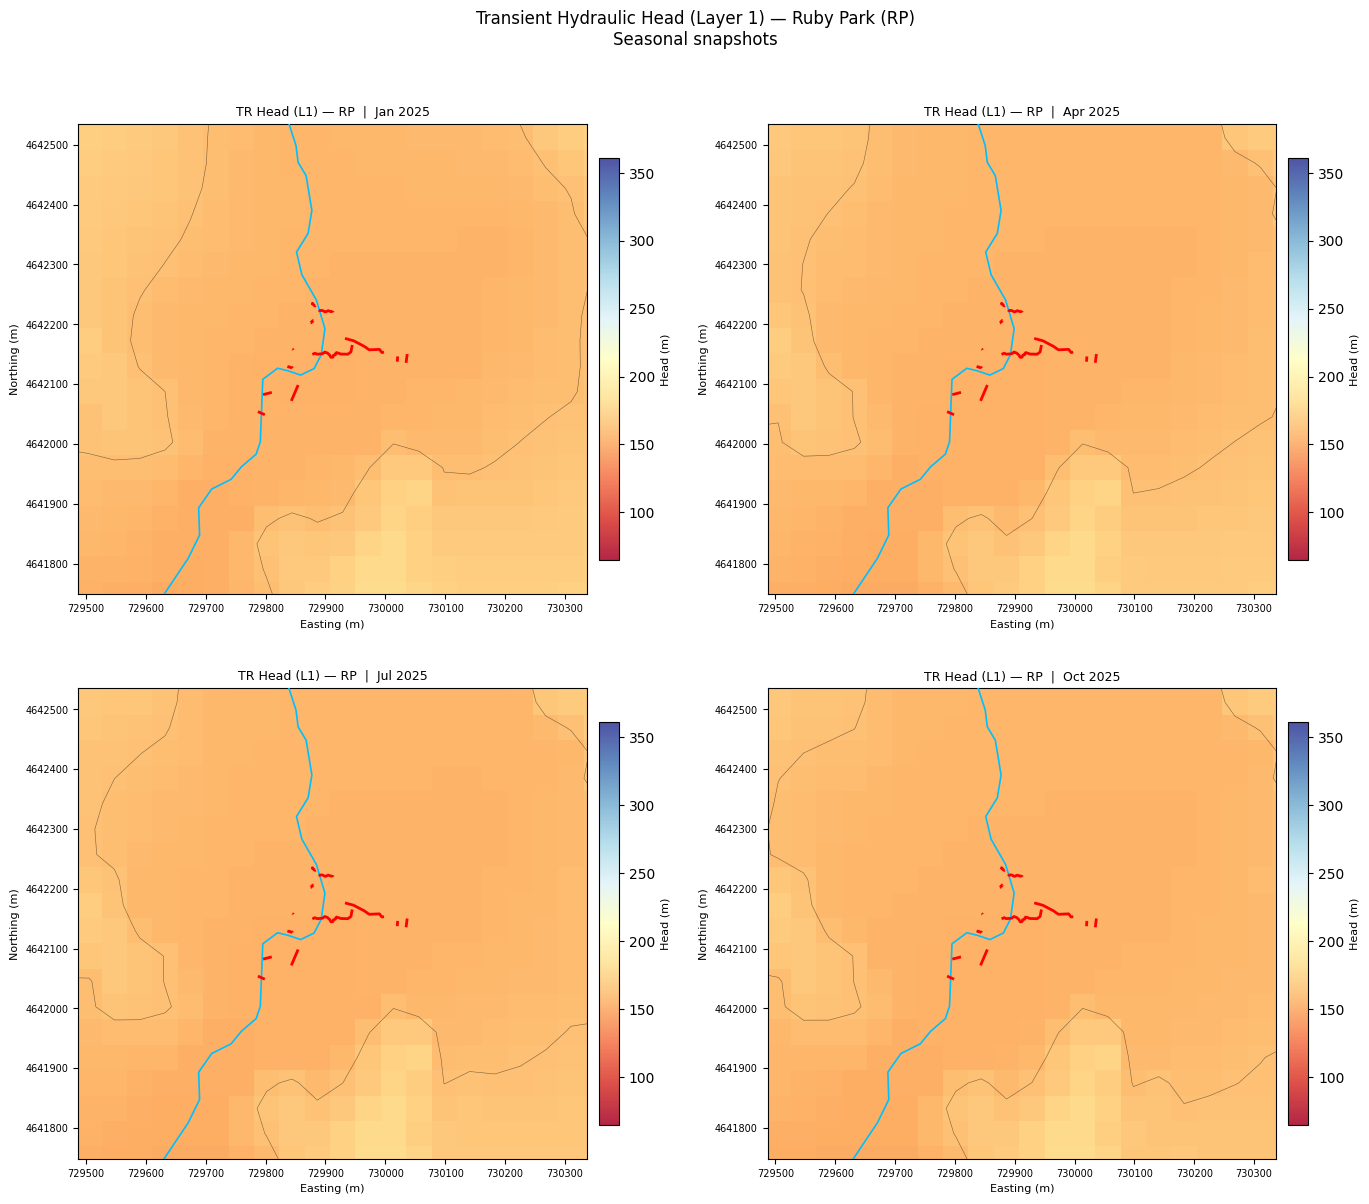

In [19]:
# ── TR head Layer 1, 4 seasonal snapshots — RP ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, isp in zip(axes.flat, sp_plot):
    h = hds_tr_all[isp]
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    pa = mm.plot_array(h, cmap='RdYlBu', vmin=vmin_h, vmax=vmax_h, alpha=0.85)
    levels = np.linspace(vmin_h, vmax_h, 10)
    try:
        mm.contour_array(h, levels=levels, colors='k', linewidths=0.4, alpha=0.5)
    except Exception:
        pass
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_rp.plot(ax=ax, color='red', lw=2.0, zorder=5)
    ax.set_xlim(ext_rp[0], ext_rp[1])
    ax.set_ylim(ext_rp[2], ext_rp[3])
    ax.set_title(f'TR Head (L1) — RP  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)

plt.suptitle('Transient Hydraulic Head (Layer 1) — Ruby Park (RP)\nSeasonal snapshots',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

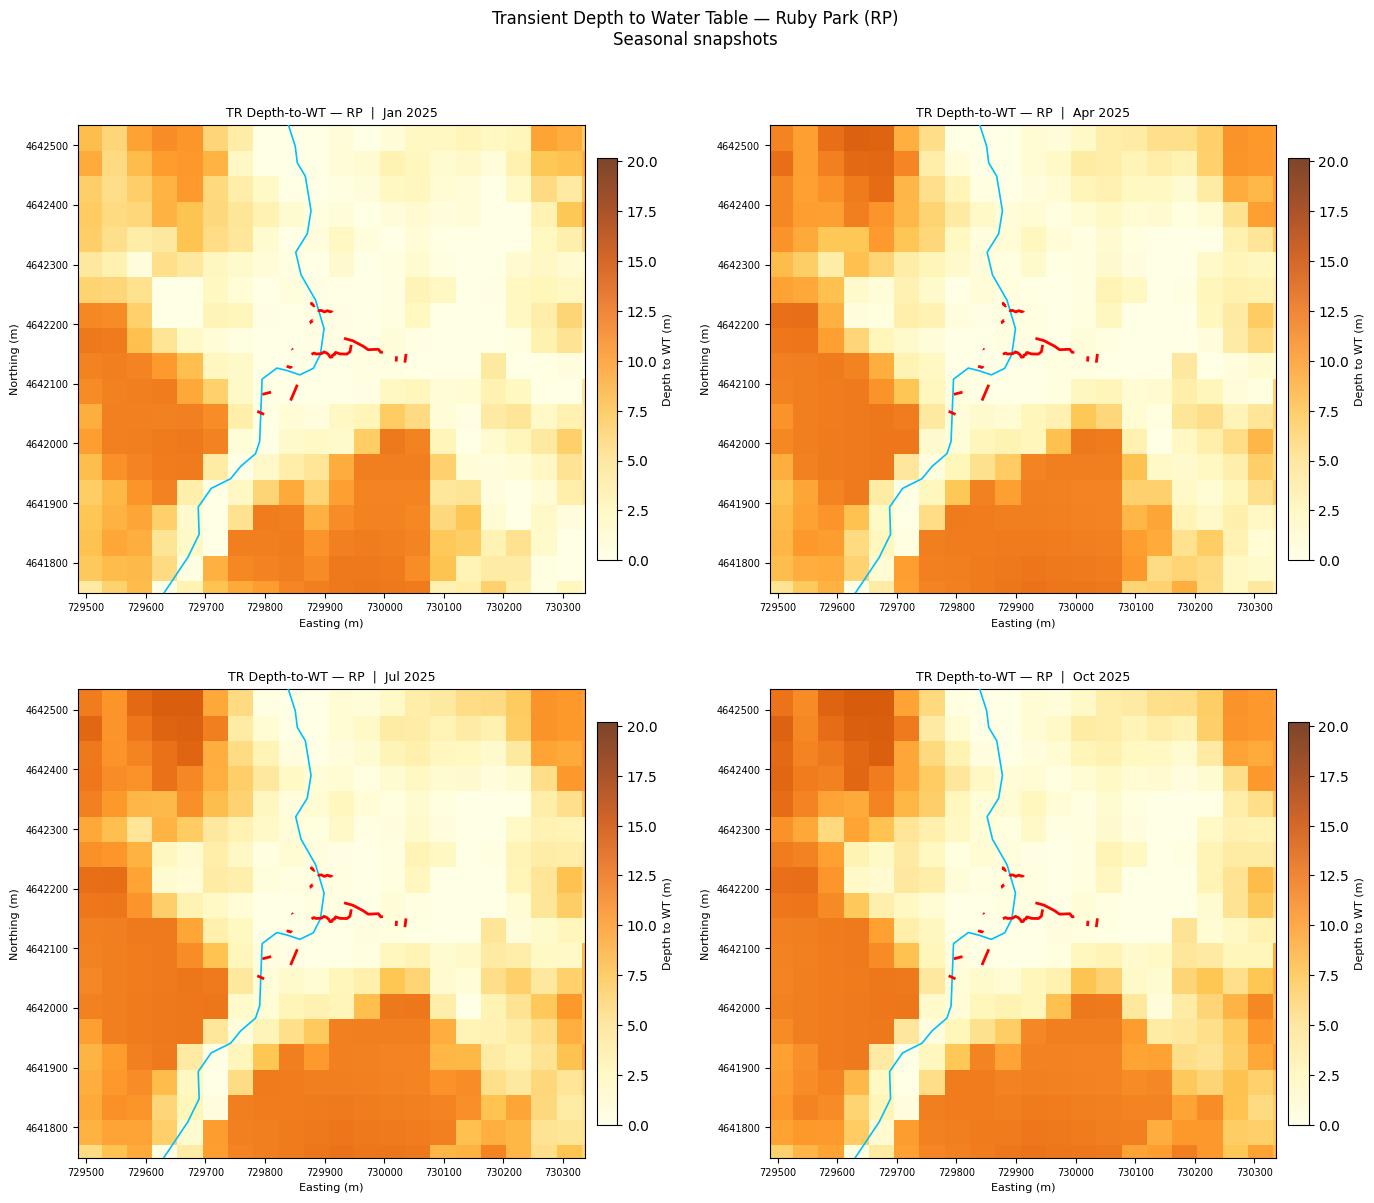

In [20]:
# ── TR depth to water table, 4 seasonal snapshots — RP ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, isp in zip(axes.flat, sp_plot):
    wt = wt_tr_all[isp]
    depth = np.clip(top_2d - wt, 0, None)
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    pa = mm.plot_array(depth[np.newaxis, :, :], cmap='YlOrBr',
                       vmin=vmin_d, vmax=vmax_d, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_rp.plot(ax=ax, color='red', lw=2.0, zorder=5)
    ax.set_xlim(ext_rp[0], ext_rp[1])
    ax.set_ylim(ext_rp[2], ext_rp[3])
    ax.set_title(f'TR Depth-to-WT — RP  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Depth to WT (m)', fontsize=8)

plt.suptitle('Transient Depth to Water Table — Ruby Park (RP)\nSeasonal snapshots',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

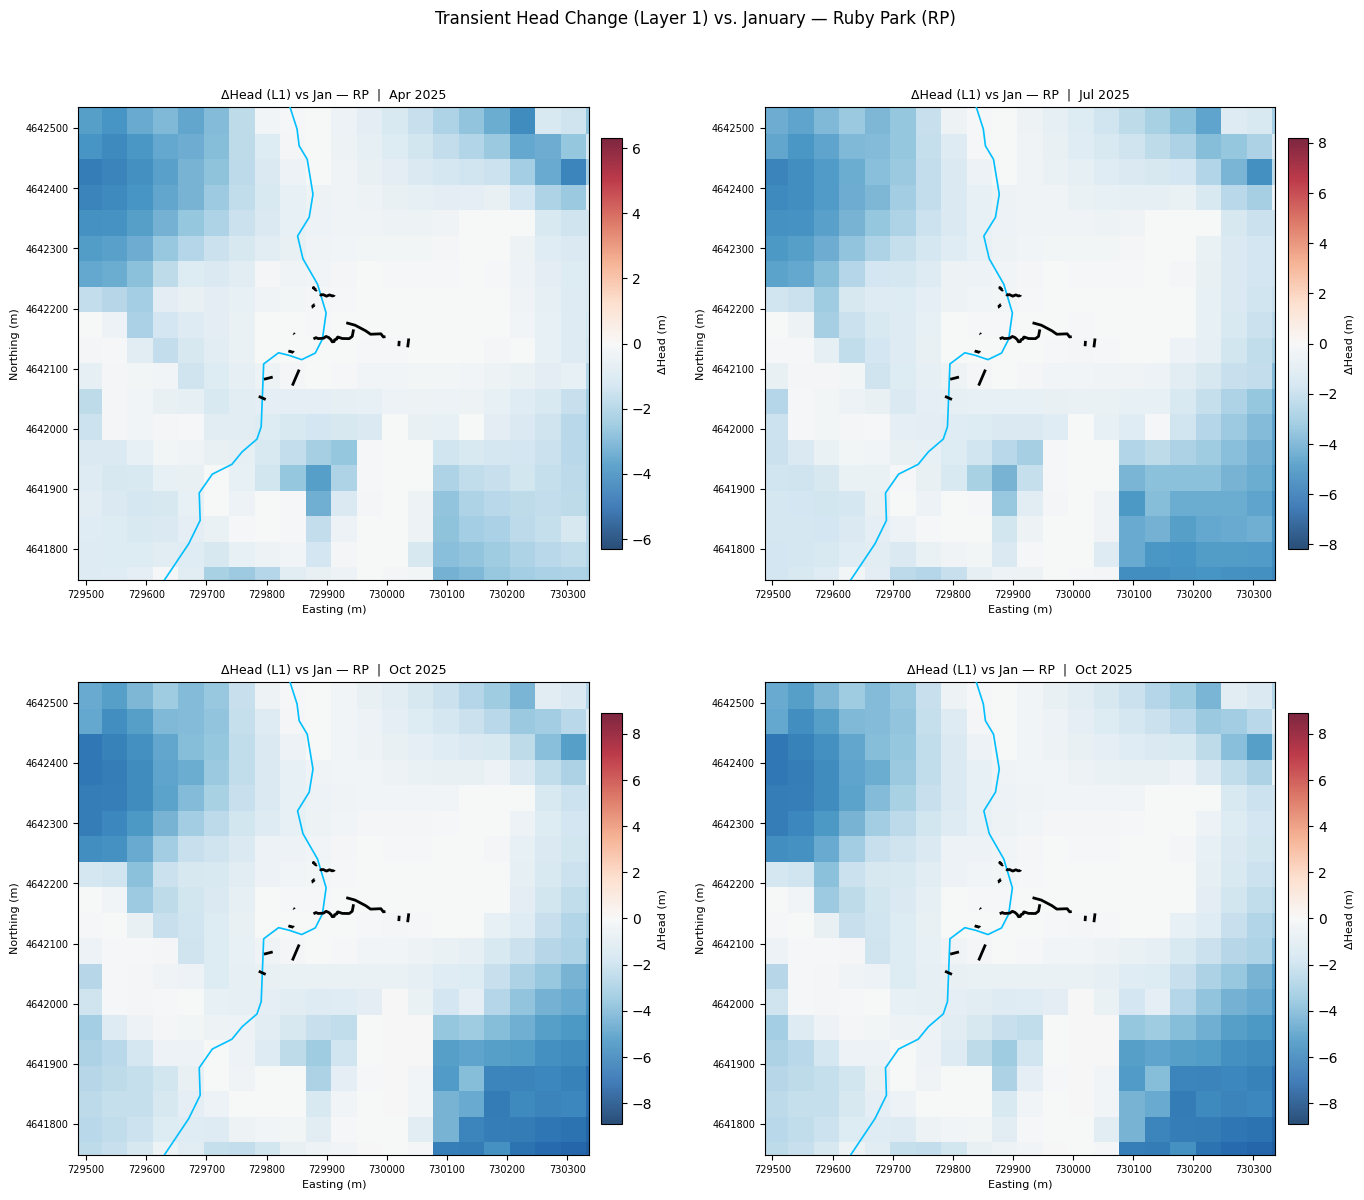

In [21]:
# ── TR head change vs. first step — RP ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, isp in zip(axes.flat, sp_plot[1:] + [sp_plot[-1]]):
    dh = hds_tr_all[isp][0] - h_ref
    mm = PlotMapView(model=gwf_tr, layer=0, ax=ax)
    lim = np.nanpercentile(np.abs(dh), 95)
    pa = mm.plot_array(dh[np.newaxis, :, :], cmap='RdBu_r',
                       vmin=-lim, vmax=lim, alpha=0.85)
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    beaver_rp.plot(ax=ax, color='k', lw=2.0, zorder=5)
    ax.set_xlim(ext_rp[0], ext_rp[1])
    ax.set_ylim(ext_rp[2], ext_rp[3])
    ax.set_title(f'ΔHead (L1) vs Jan — RP  |  {month_labels[isp]}', fontsize=9)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('ΔHead (m)', fontsize=8)

plt.suptitle('Transient Head Change (Layer 1) vs. January — Ruby Park (RP)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 9  Side-by-Side Comparison: UC vs RP
Steady-state and end-of-year transient, Layer 1 head.

In [ ]:
# ── 2×2 comparison: [SS, TR-Dec] × [UC, RP] ────────────────────────────────
isp_dec = min(11, n_sp - 1)   # December (last stress period)

all_h = [hds_ss[0], hds_tr_all[isp_dec][0]]
vmin_c = min(np.nanmin(h) for h in all_h)
vmax_c = max(np.nanmax(h) for h in all_h)

fig, axes = plt.subplots(2, 2, figsize=(15, 14))
configs = [
    (gwf_ss, hds_ss,               ext_uc, beaver_uc, 'SS  |  UC (UConn Forest)'),
    (gwf_ss, hds_ss,               ext_rp, beaver_rp, 'SS  |  RP (Ruby Park)'),
    (gwf_tr, hds_tr_all[isp_dec],  ext_uc, beaver_uc, f'TR {month_labels[isp_dec]}  |  UC'),
    (gwf_tr, hds_tr_all[isp_dec],  ext_rp, beaver_rp, f'TR {month_labels[isp_dec]}  |  RP'),
]

for ax, (gwf, h, ext, bdam, title) in zip(axes.flat, configs):
    mm = PlotMapView(model=gwf, layer=0, ax=ax)
    pa = mm.plot_array(h, cmap='RdYlBu', vmin=vmin_c, vmax=vmax_c, alpha=0.85)
    levels = np.linspace(vmin_c, vmax_c, 12)
    try:
        mm.contour_array(h, levels=levels, colors='k', linewidths=0.4, alpha=0.5)
    except Exception:
        pass
    streams.plot(ax=ax, color='deepskyblue', lw=1.2, zorder=4)
    bdam.plot(ax=ax, color='red', lw=2.0, zorder=5)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    plt.colorbar(pa, ax=ax, shrink=0.75, pad=0.02).set_label('Head (m)', fontsize=8)

plt.suptitle('Hydraulic Head (Layer 1): UC vs RP  |  Steady-State and Transient',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()